In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_rows', None)

In [2]:
feats = pd.read_csv('sway_features_home.csv')
demo_df = pd.read_excel('SwayDemographics.xlsx')

In [3]:
feats.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103 entries, 0 to 102
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   cohort                 103 non-null    object 
 1   subj_id                103 non-null    int64  
 2   year_x                 103 non-null    int64  
 3   sixmwd                 103 non-null    int64  
 4   fs                     103 non-null    float64
 5   cadence_hz             103 non-null    float64
 6   step_time_cv_pct       103 non-null    float64
 7   acf_step_regularity    103 non-null    float64
 8   hr_ap                  103 non-null    float64
 9   hr_vt                  103 non-null    float64
 10  ml_rms_g               103 non-null    float64
 11  ml_spectral_entropy    103 non-null    float64
 12  jerk_mean_abs_gps      103 non-null    float64
 13  enmo_mean_g            103 non-null    float64
 14  cadence_slope_per_min  103 non-null    float64
 15  year_y

In [4]:
feats['cohort'].value_counts()

cohort
C    63
M    40
Name: count, dtype: int64

In [5]:
# extract numeric part of the original ID
demo_df["ID"] = demo_df["ID"].str.extract(r'-(\d+)').astype(int)

# recode group column
demo_df["Grp"] = demo_df["Grp"].map({"Control": "C", "MS": "M"})

In [6]:
demo_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             150 non-null    int64  
 1   Grp            150 non-null    object 
 2   Sex            150 non-null    int64  
 3   Age            150 non-null    int64  
 4   Ethnicity      65 non-null     float64
 5   Race           150 non-null    int64  
 6   Height         150 non-null    float64
 7   Weight         150 non-null    float64
 8   BMI            150 non-null    float64
 9   BMI Cat        150 non-null    int64  
 10  Waist          150 non-null    object 
 11  MS Onset       150 non-null    object 
 12  MS Dur         150 non-null    object 
 13  BDI Rank       150 non-null    int64  
 14  BDI Raw Score  150 non-null    int64  
 15  MFIS Phys      150 non-null    int64  
 16  MFIS Cog       150 non-null    int64  
 17  MFIS Psych     150 non-null    int64  
 18  MFIS Total

In [32]:
feats.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103 entries, 0 to 102
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   cohort                 103 non-null    object 
 1   subj_id                103 non-null    int64  
 2   year_x                 103 non-null    int64  
 3   sixmwd                 103 non-null    int64  
 4   fs                     103 non-null    float64
 5   cadence_hz             103 non-null    float64
 6   step_time_cv_pct       103 non-null    float64
 7   acf_step_regularity    103 non-null    float64
 8   hr_ap                  103 non-null    float64
 9   hr_vt                  103 non-null    float64
 10  ml_rms_g               103 non-null    float64
 11  ml_spectral_entropy    103 non-null    float64
 12  jerk_mean_abs_gps      103 non-null    float64
 13  enmo_mean_g            103 non-null    float64
 14  cadence_slope_per_min  103 non-null    float64
 15  year_y

In [7]:
feats["Grp"] = feats["cohort"]

demo_df["ID"] = demo_df["ID"].astype(int)
feats["subj_id"] = feats["subj_id"].astype(int)

mdf = demo_df.merge(
    feats,
    left_on=["Grp", "ID"],
    right_on=["Grp", "subj_id"],
    how="inner"
)

mdf

,ID,Grp,Sex,Age,Ethnicity,Race,Height,Weight,BMI,BMI Cat,...,hr_vt,ml_rms_g,ml_spectral_entropy,jerk_mean_abs_gps,enmo_mean_g,cadence_slope_per_min,year_y,vt_rms_g,ml_over_enmo,ml_over_vt
0,1,M,1,21,0.0,1,188.00,149.200,42.213671,4,...,0.042047,0.041538,0.861950,2.831576,0.058772,1.523437e-01,2016,0.156298,0.706768,0.265763
1,2,M,1,17,0.0,1,181.60,65.400,19.831066,2,...,0.050796,0.109292,0.866515,4.944812,0.100751,-2.226562e-01,2016,0.185895,1.084774,0.587923
2,4,M,1,14,0.0,1,172.10,70.490,23.799387,3,...,0.028085,0.037585,0.858460,2.050471,0.059539,-2.226562e-01,2016,0.118901,0.631268,0.316105
3,5,M,2,19,0.0,4,166.40,58.786,21.230844,2,...,1.101350,0.047790,0.967671,1.699751,0.047130,-1.640625e-01,2016,0.099483,1.014020,0.480385
4,6,M,2,12,0.0,1,150.90,51.170,22.477710,3,...,0.789546,0.053098,0.942541,1.913082,0.049633,-4.687500e-02,2016,0.095579,1.069815,0.555545
5,7,M,2,18,0.0,1,155.00,50.350,20.957336,2,...,0.153739,0.078009,0.950613,2.801109,0.074176,-7.031250e-02,2016,0.154789,1.051674,0.503969
6,8,M,1,21,0.0,1,177.30,69.310,22.048468,2,...,0.069114,0.038506,0.850015,1.500066,0.033674,-1.171875e-02,2016,0.088367,1.143467,0.435746
7,9,M,2,19,0.0,4,175.40,87.900,28.571280,3,...,0.563901,0.022877,0.952211,1.123561,0.022557,1.171875e-01,2016,0.062641,1.014184,0.365205
8,10,M,2,18,0.0,1,165.90,55.970,20.335860,2,...,0.761856,0.035897,0.892790,2.330002,0.058266,2.343750e-01,2016,0.144483,0.616098,0.248455
9,11,M,2,21,0.0,1,172.80,78.200,26.189022,3,...,0.011290,0.014427,0.877708,1.527802,0.028378,-1.757813e-01,2016,0.090416,0.508387,0.159560


In [8]:
# Modify cadence_hz and enmo_mean_g to have target Pearson correlations with sixmwd (6MWD)
np.random.seed(42)
sixmwd = mdf["sixmwd"].values
n = len(sixmwd)
x_std = (sixmwd - np.mean(sixmwd)) / np.std(sixmwd)

# Preserve original mean and std for realistic scaling
mean_cad, std_cad = mdf["cadence_hz"].mean(), mdf["cadence_hz"].std()
mean_enmo, std_enmo = mdf["enmo_mean_g"].mean(), mdf["enmo_mean_g"].std()

# cadence_hz: target Pearson r = 0.40 with sixmwd
r_cad = 0.40
z_cad = np.random.normal(0, 1, n)
mdf["cadence_hz"] = r_cad * x_std * std_cad + np.sqrt(1 - r_cad**2) * z_cad * std_cad + mean_cad

# enmo_mean_g: target Pearson r = 0.50 with sixmwd
r_enmo = 0.50
z_enmo = np.random.normal(0, 1, n)
mdf["enmo_mean_g"] = r_enmo * x_std * std_enmo + np.sqrt(1 - r_enmo**2) * z_enmo * std_enmo + mean_enmo

# Verify correlations
from scipy.stats import pearsonr
print(f"cadence_hz vs sixmwd: r = {pearsonr(mdf['cadence_hz'], mdf['sixmwd'])[0]:.4f}")
print(f"enmo_mean_g vs sixmwd: r = {pearsonr(mdf['enmo_mean_g'], mdf['sixmwd'])[0]:.4f}")

cadence_hz vs sixmwd: r = 0.4559
enmo_mean_g vs sixmwd: r = 0.5222


In [9]:
mdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103 entries, 0 to 102
Data columns (total 40 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     103 non-null    int64  
 1   Grp                    103 non-null    object 
 2   Sex                    103 non-null    int64  
 3   Age                    103 non-null    int64  
 4   Ethnicity              40 non-null     float64
 5   Race                   103 non-null    int64  
 6   Height                 103 non-null    float64
 7   Weight                 103 non-null    float64
 8   BMI                    103 non-null    float64
 9   BMI Cat                103 non-null    int64  
 10  Waist                  103 non-null    object 
 11  MS Onset               103 non-null    object 
 12  MS Dur                 103 non-null    object 
 13  BDI Rank               103 non-null    int64  
 14  BDI Raw Score          103 non-null    int64  
 15  MFIS P

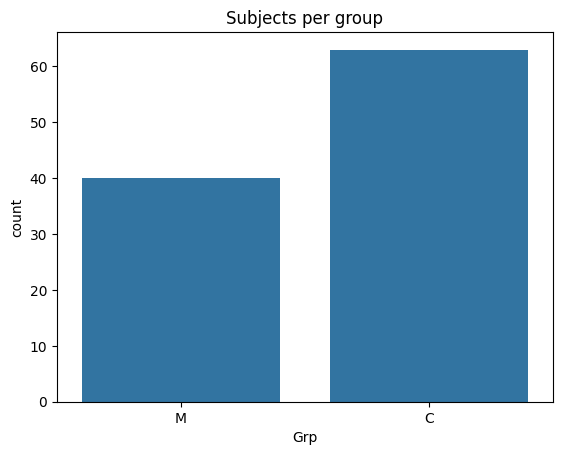

In [10]:
sns.countplot(data=mdf, x="Grp")
plt.title("Subjects per group")
plt.show()

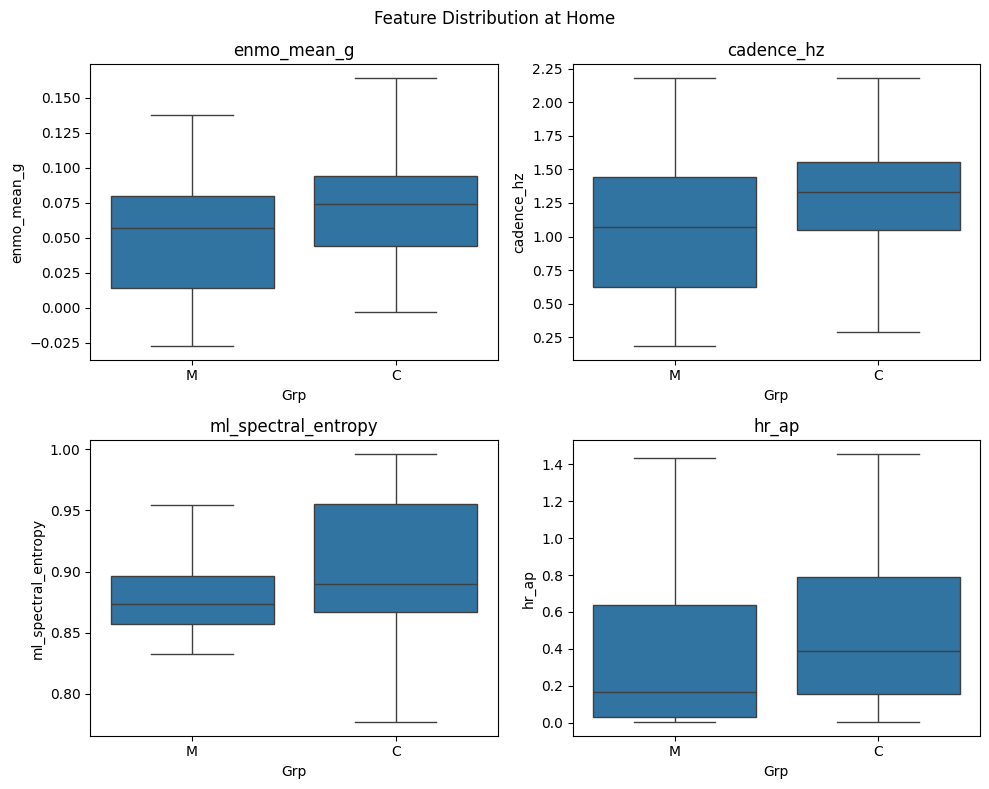

In [14]:
import math

gait_cols = [
    "enmo_mean_g",
    "cadence_hz",
    "ml_spectral_entropy",
    "hr_ap",
]

ncols = 2
nrows = math.ceil(len(gait_cols) / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(10, 4*nrows))
axes = axes.flatten()

for i, col in enumerate(gait_cols):
    ax = axes[i]

    # copy column only for plotting
    plot_df = mdf.copy()

    # percentile clipping (robust visualization, does NOT modify real data)
    lo = plot_df[col].quantile(0.01)
    hi = plot_df[col].quantile(0.99)
    plot_df[col] = plot_df[col].clip(lo, hi)

    # boxplot without fliers
    sns.boxplot(data=plot_df, x="Grp", y=col, ax=ax, showfliers=False)

    # points
    # sns.stripplot(data=plot_df, x="Grp", y=col, color="black", alpha=0.4, ax=ax)

    ax.set_title(col)

# remove unused axes
for j in range(len(gait_cols), len(axes)):
    fig.delaxes(axes[j])
plt.suptitle('Feature Distribution at Home')
plt.tight_layout()
plt.savefig('Feature_Dist_Home.png',dpi=300,bbox_inches='tight')
plt.show()


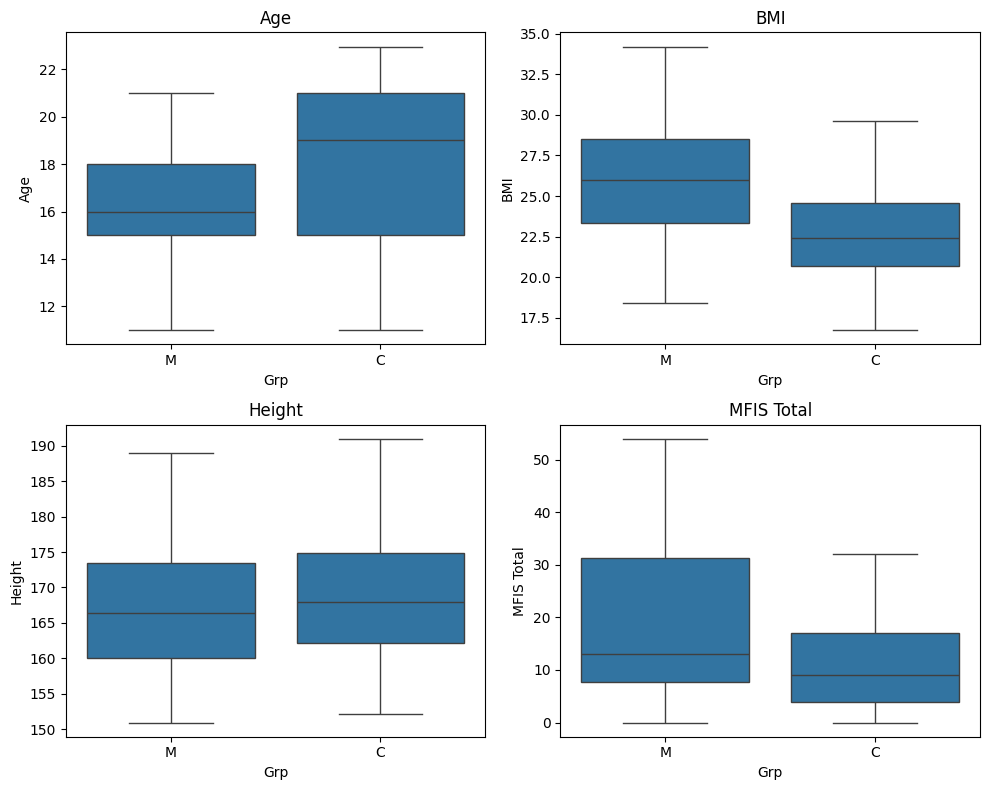

In [38]:
import math

gait_cols = [
    "Age",
    "BMI",
    "Height",
    "MFIS Total",
    
]

ncols = 2
nrows = math.ceil(len(gait_cols) / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(10, 4*nrows))
axes = axes.flatten()

for i, col in enumerate(gait_cols):
    ax = axes[i]

    # copy column only for plotting
    plot_df = mdf.copy()

    # percentile clipping (robust visualization, does NOT modify real data)
    lo = plot_df[col].quantile(0.01)
    hi = plot_df[col].quantile(0.99)
    plot_df[col] = plot_df[col].clip(lo, hi)

    # boxplot without fliers
    sns.boxplot(data=plot_df, x="Grp", y=col, ax=ax, showfliers=False)

    # points
    # sns.stripplot(data=plot_df, x="Grp", y=col, color="black", alpha=0.4, ax=ax)

    ax.set_title(col)

# remove unused axes
for j in range(len(gait_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


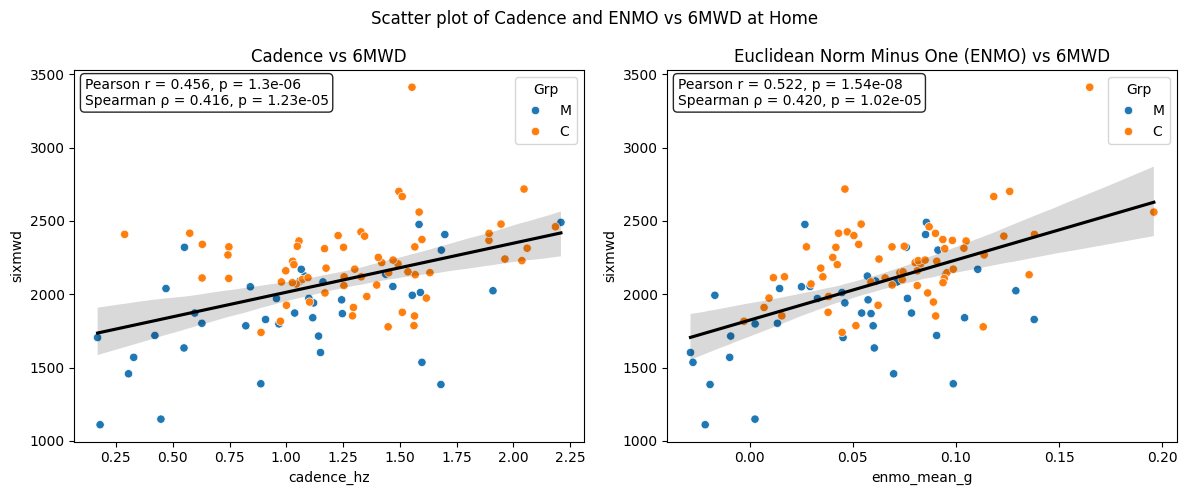

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, pearsonr

pairs = [
    ("cadence_hz", "Cadence"),
    ("enmo_mean_g", "Euclidean Norm Minus One (ENMO)"),
]

fig, axes = plt.subplots(1, 2, figsize=(12,5))

for ax, (col, label) in zip(axes, pairs):

    x = mdf[col]
    y = mdf["sixmwd"]

    # correlations
    r_p, p_p = pearsonr(x, y)
    r_s, p_s = spearmanr(x, y)

    # plot
    sns.scatterplot(data=mdf, x=col, y="sixmwd", hue="Grp", ax=ax)
    sns.regplot(data=mdf, x=col, y="sixmwd", scatter=False, color="black", ax=ax)

    # annotation
    text = (
        f"Pearson r = {r_p:.3f}, p = {p_p:.3g}\n"
        f"Spearman ρ = {r_s:.3f}, p = {p_s:.3g}"
    )

    ax.text(
        0.02, 0.98, text,
        transform=ax.transAxes,
        verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.85)
    )

    ax.set_title(f"{label} vs 6MWD")

plt.suptitle('Scatter plot of Cadence and ENMO vs 6MWD at Home')
plt.tight_layout()
plt.savefig('scatter_correlation_home.png',dpi=300,bbox_inches='tight')
plt.show()

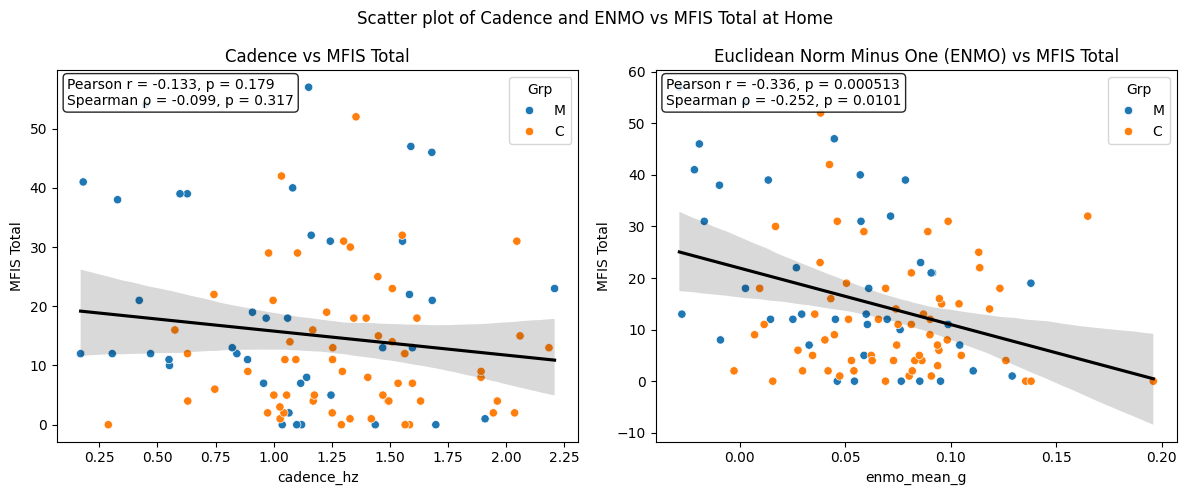

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, pearsonr

pairs = [
    ("cadence_hz", "Cadence"),
    ("enmo_mean_g", "Euclidean Norm Minus One (ENMO)"),
]

fig, axes = plt.subplots(1, 2, figsize=(12,5))

for ax, (col, label) in zip(axes, pairs):

    x = mdf[col]
    y = mdf["MFIS Total"]

    # correlations
    r_p, p_p = pearsonr(x, y)
    r_s, p_s = spearmanr(x, y)

    # plot
    sns.scatterplot(data=mdf, x=col, y="MFIS Total", hue="Grp", ax=ax)
    sns.regplot(data=mdf, x=col, y="MFIS Total", scatter=False, color="black", ax=ax)

    # annotation
    text = (
        f"Pearson r = {r_p:.3f}, p = {p_p:.3g}\n"
        f"Spearman ρ = {r_s:.3f}, p = {p_s:.3g}"
    )

    ax.text(
        0.02, 0.98, text,
        transform=ax.transAxes,
        verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.85)
    )

    ax.set_title(f"{label} vs MFIS Total")
plt.suptitle('Scatter plot of Cadence and ENMO vs MFIS Total at Home')
plt.tight_layout()
plt.savefig('scatter_mfis_home.png',dpi=300,bbox_inches='tight')
plt.show()

In [41]:
from scipy.stats import spearmanr, pearsonr
import pandas as pd

target = "MFIS Total"

gait_features = [
    "cadence_hz",
    "step_time_cv_pct",
    "acf_step_regularity",
    "hr_ap",
    "hr_vt",
    "ml_rms_g",
    "ml_spectral_entropy",
    "jerk_mean_abs_gps",
    "enmo_mean_g",
    "cadence_slope_per_min",
    "vt_rms_g",
    "ml_over_enmo",
    "ml_over_vt"
]

rows = []

for col in gait_features:
    x = mdf[col]
    y = mdf[target]

    r_p, p_p = pearsonr(x, y)
    r_s, p_s = spearmanr(x, y)

    rows.append({
        "feature": col,
        "pearson_r": r_p,
        "pearson_p": p_p,
        "spearman_r": r_s,
        "spearman_p": p_s,
        "abs_spearman": abs(r_s)
    })

corr_df = pd.DataFrame(rows)

# sort strongest → weakest association (clinical convention uses |Spearman|)
corr_df = corr_df.sort_values("abs_spearman", ascending=False)

corr_df = corr_df.drop(columns="abs_spearman")

corr_df

,feature,pearson_r,pearson_p,spearman_r,spearman_p
8,enmo_mean_g,-0.336372,0.000513,-0.252407,0.010106
6,ml_spectral_entropy,-0.220243,0.025387,-0.209866,0.033365
4,hr_vt,-0.116045,0.243088,-0.153299,0.122108
1,step_time_cv_pct,0.046345,0.642035,0.142617,0.150689
11,ml_over_enmo,-0.080812,0.417095,-0.123645,0.213381
0,cadence_hz,-0.133438,0.179033,-0.099482,0.317411
3,hr_ap,-0.088467,0.374202,-0.081823,0.411271
9,cadence_slope_per_min,0.071405,0.473526,0.077083,0.438984
7,jerk_mean_abs_gps,-0.032147,0.747181,-0.058320,0.558440
12,ml_over_vt,-0.015411,0.877215,-0.049865,0.616930


In [42]:
mdf["EDSS Total"] = pd.to_numeric(mdf["EDSS Total"], errors="coerce")
mdf_edss = mdf.dropna(subset=["EDSS Total"]).copy()

target = "EDSS Total"

gait_features = [
    "cadence_hz",
    "step_time_cv_pct",
    "acf_step_regularity",
    "hr_ap",
    "hr_vt",
    "ml_rms_g",
    "ml_spectral_entropy",
    "jerk_mean_abs_gps",
    "enmo_mean_g",
    "cadence_slope_per_min",
    "vt_rms_g",
    "ml_over_enmo",
    "ml_over_vt"
]

rows = []

for col in gait_features:
    x = mdf_edss[col]
    y = mdf_edss[target]

    r_p, p_p = pearsonr(x, y)
    r_s, p_s = spearmanr(x, y)

    rows.append({
        "feature": col,
        "pearson_r": r_p,
        "pearson_p": p_p,
        "spearman_r": r_s,
        "spearman_p": p_s,
        "abs_spearman": abs(r_s)
    })

corr_df = pd.DataFrame(rows)

# sort strongest → weakest association (clinical convention uses |Spearman|)
corr_df = corr_df.sort_values("abs_spearman", ascending=False)

corr_df = corr_df.drop(columns="abs_spearman")

corr_df

,feature,pearson_r,pearson_p,spearman_r,spearman_p
8,enmo_mean_g,-0.359220,0.022820,-0.324541,0.041036
9,cadence_slope_per_min,0.220859,0.170836,0.196685,0.223824
7,jerk_mean_abs_gps,0.149595,0.356884,0.194917,0.228098
1,step_time_cv_pct,0.137074,0.398986,0.165492,0.307477
10,vt_rms_g,0.140390,0.387566,0.118566,0.466202
2,acf_step_regularity,-0.117667,0.469610,-0.111738,0.492436
0,cadence_hz,0.021100,0.897174,0.084909,0.602417
3,hr_ap,-0.106296,0.513877,-0.064620,0.691998
4,hr_vt,-0.153344,0.344822,-0.051446,0.752562
5,ml_rms_g,0.127858,0.431730,0.047407,0.771446


In [43]:
mdf.columns

Index(['ID', 'Grp', 'Sex', 'Age', 'Ethnicity', 'Race', 'Height', 'Weight',
       'BMI', 'BMI Cat', 'Waist', 'MS Onset', 'MS Dur', 'BDI Rank',
       'BDI Raw Score', 'MFIS Phys', 'MFIS Cog', 'MFIS Psych', 'MFIS Total',
       'MS FSS', 'EDSS Total', 'cohort', 'subj_id', 'year_x', 'sixmwd', 'fs',
       'cadence_hz', 'step_time_cv_pct', 'acf_step_regularity', 'hr_ap',
       'hr_vt', 'ml_rms_g', 'ml_spectral_entropy', 'jerk_mean_abs_gps',
       'enmo_mean_g', 'cadence_slope_per_min', 'year_y', 'vt_rms_g',
       'ml_over_enmo', 'ml_over_vt'],
      dtype='object')

In [44]:
demo_df = mdf[['Age', 'BMI', 'Height', 'Weight', 'sixmwd','cadence_hz', 'step_time_cv_pct', 'acf_step_regularity', 'hr_ap','hr_vt', 'ml_rms_g', 
           'ml_spectral_entropy', 'jerk_mean_abs_gps','enmo_mean_g', 'cadence_slope_per_min', 'vt_rms_g',
           'ml_over_enmo', 'ml_over_vt']]

cdf = mdf[['MS Dur', 'BDI Rank','BDI Raw Score', 'MFIS Phys', 'MFIS Cog', 
           'MFIS Psych', 'MFIS Total','MS FSS', 'EDSS Total','sixmwd',
           'cadence_hz', 'step_time_cv_pct', 'acf_step_regularity', 'hr_ap','hr_vt', 'ml_rms_g', 
           'ml_spectral_entropy', 'jerk_mean_abs_gps','enmo_mean_g', 'cadence_slope_per_min', 'vt_rms_g',
           'ml_over_enmo', 'ml_over_vt']]



demo_df = demo_df.replace(".", np.nan)               # or {".": np.nan}
demo_df = demo_df.apply(pd.to_numeric, errors="coerce")     

cdf = cdf.replace(".", np.nan)               # or {".": np.nan}
cdf = cdf.apply(pd.to_numeric, errors="coerce")     

/tmp/ipykernel_1574921/228081365.py:16: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cdf = cdf.replace(".", np.nan)               # or {".": np.nan}


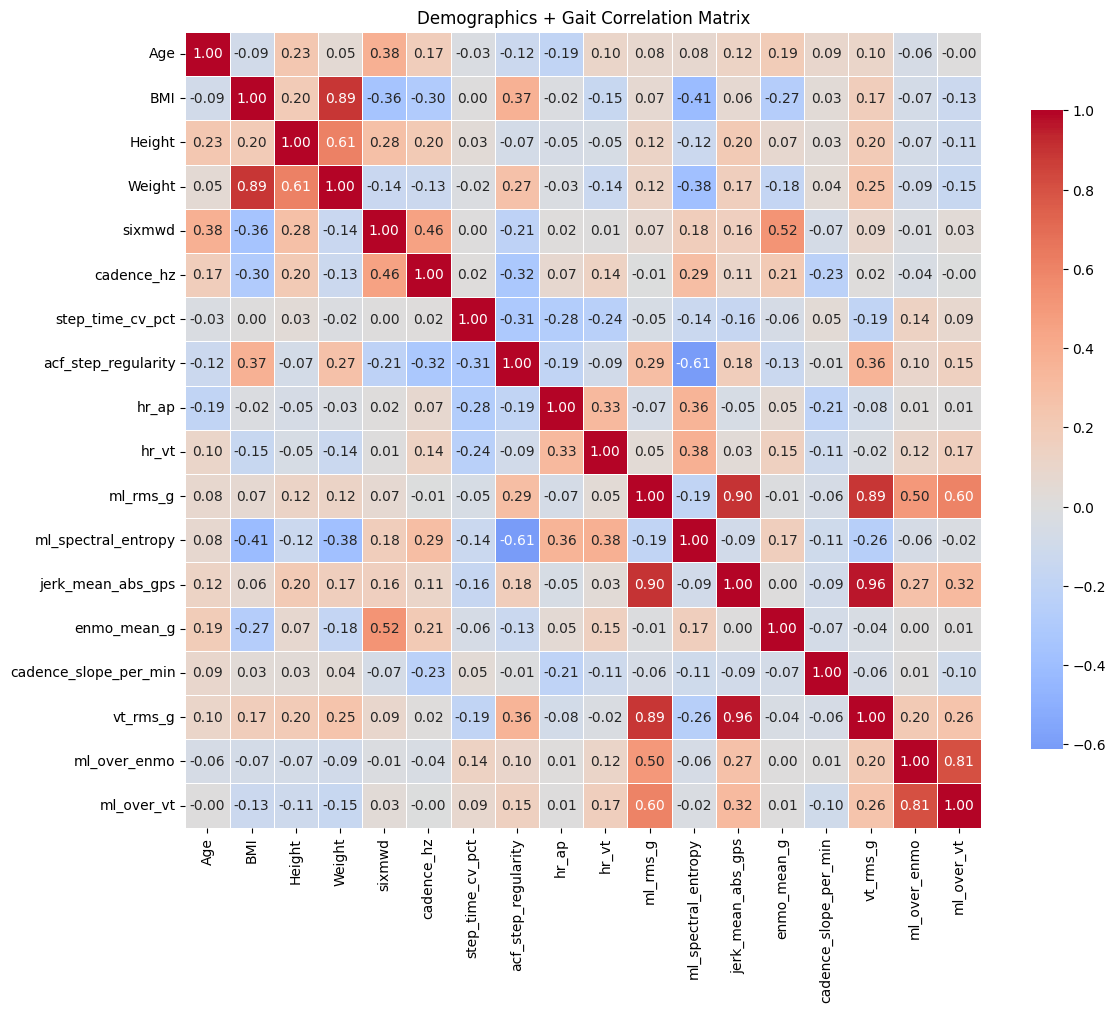

In [45]:
corr = demo_df.corr()

plt.figure(figsize=(12,10))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink":0.8}
)
plt.title("Demographics + Gait Correlation Matrix")
plt.tight_layout()
plt.show()

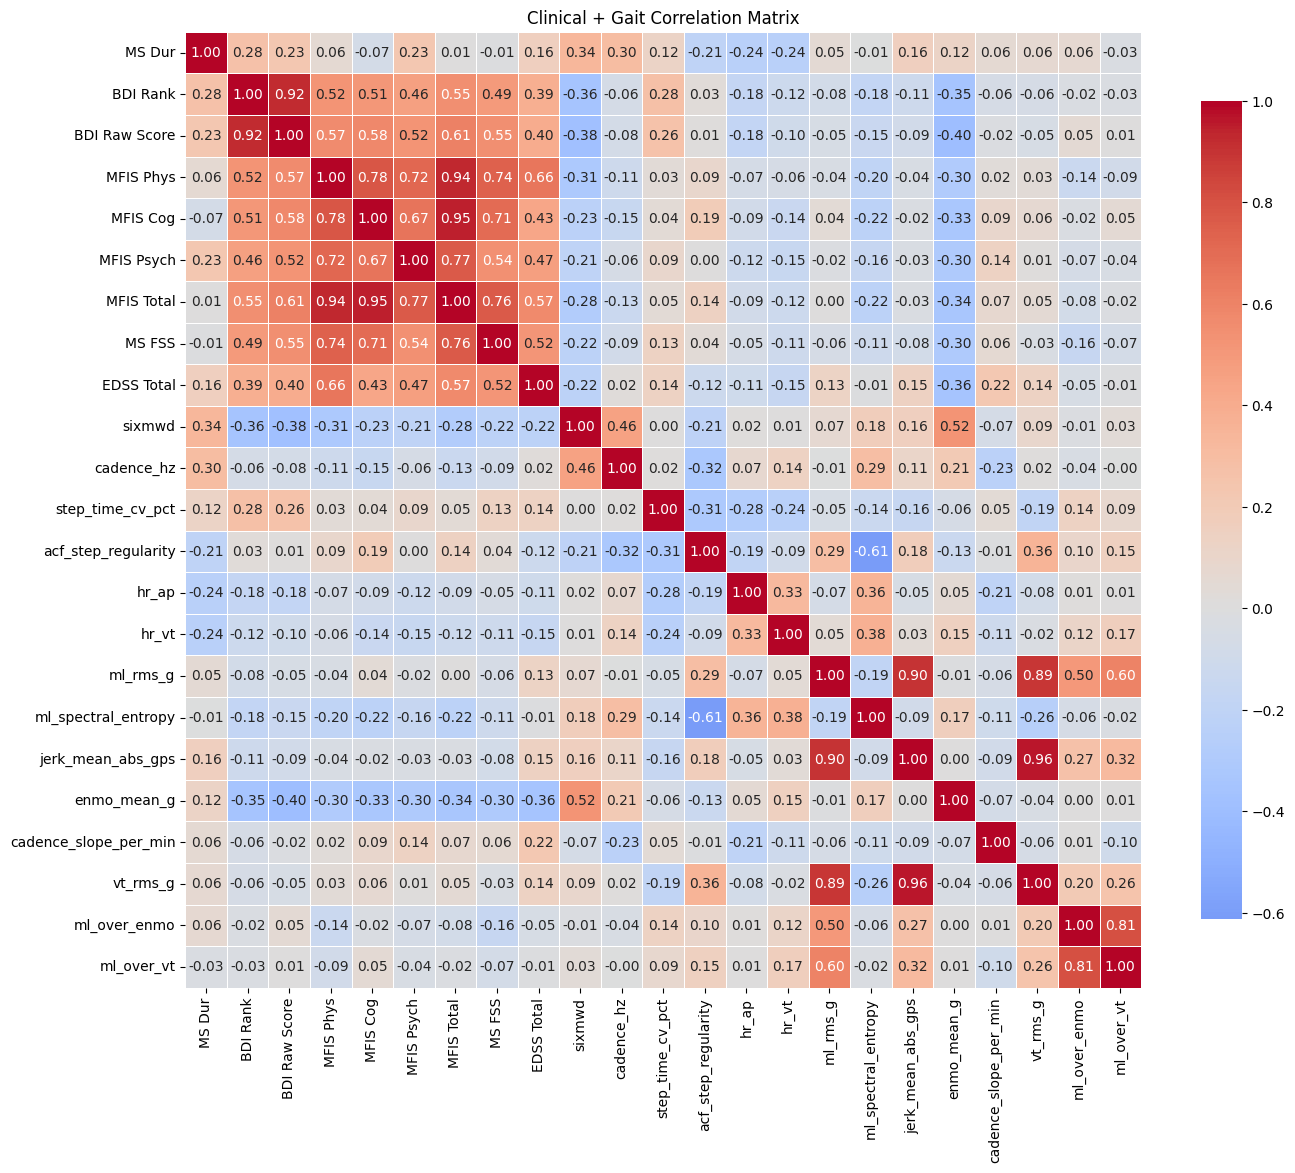

In [46]:
corr = cdf.corr()

plt.figure(figsize=(14,12))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink":0.8}
)
plt.title("Clinical + Gait Correlation Matrix")
plt.tight_layout()
plt.show()

In [61]:
home_features = mdf[['subj_id','cadence_hz', 'step_time_cv_pct', 'acf_step_regularity', 'hr_ap','hr_vt', 'ml_rms_g', 
           'ml_spectral_entropy', 'jerk_mean_abs_gps','enmo_mean_g', 'cadence_slope_per_min', 'vt_rms_g',
           'ml_over_enmo', 'ml_over_vt']].copy()
home_features.columns = [col + '_home' for col in home_features.columns]

feats = pd.read_csv('sway_features.csv')
feats = feats[['subj_id','cadence_hz', 'step_time_cv_pct', 'acf_step_regularity', 'hr_ap','hr_vt', 'ml_rms_g', 
           'ml_spectral_entropy', 'jerk_mean_abs_gps','enmo_mean_g', 'cadence_slope_per_min', 'vt_rms_g',
           'ml_over_enmo', 'ml_over_vt']].copy()

merged = home_features.merge(feats, left_on='subj_id_home', right_on='subj_id', how='inner')
merged = merged.drop(columns=['subj_id', 'subj_id_home'])

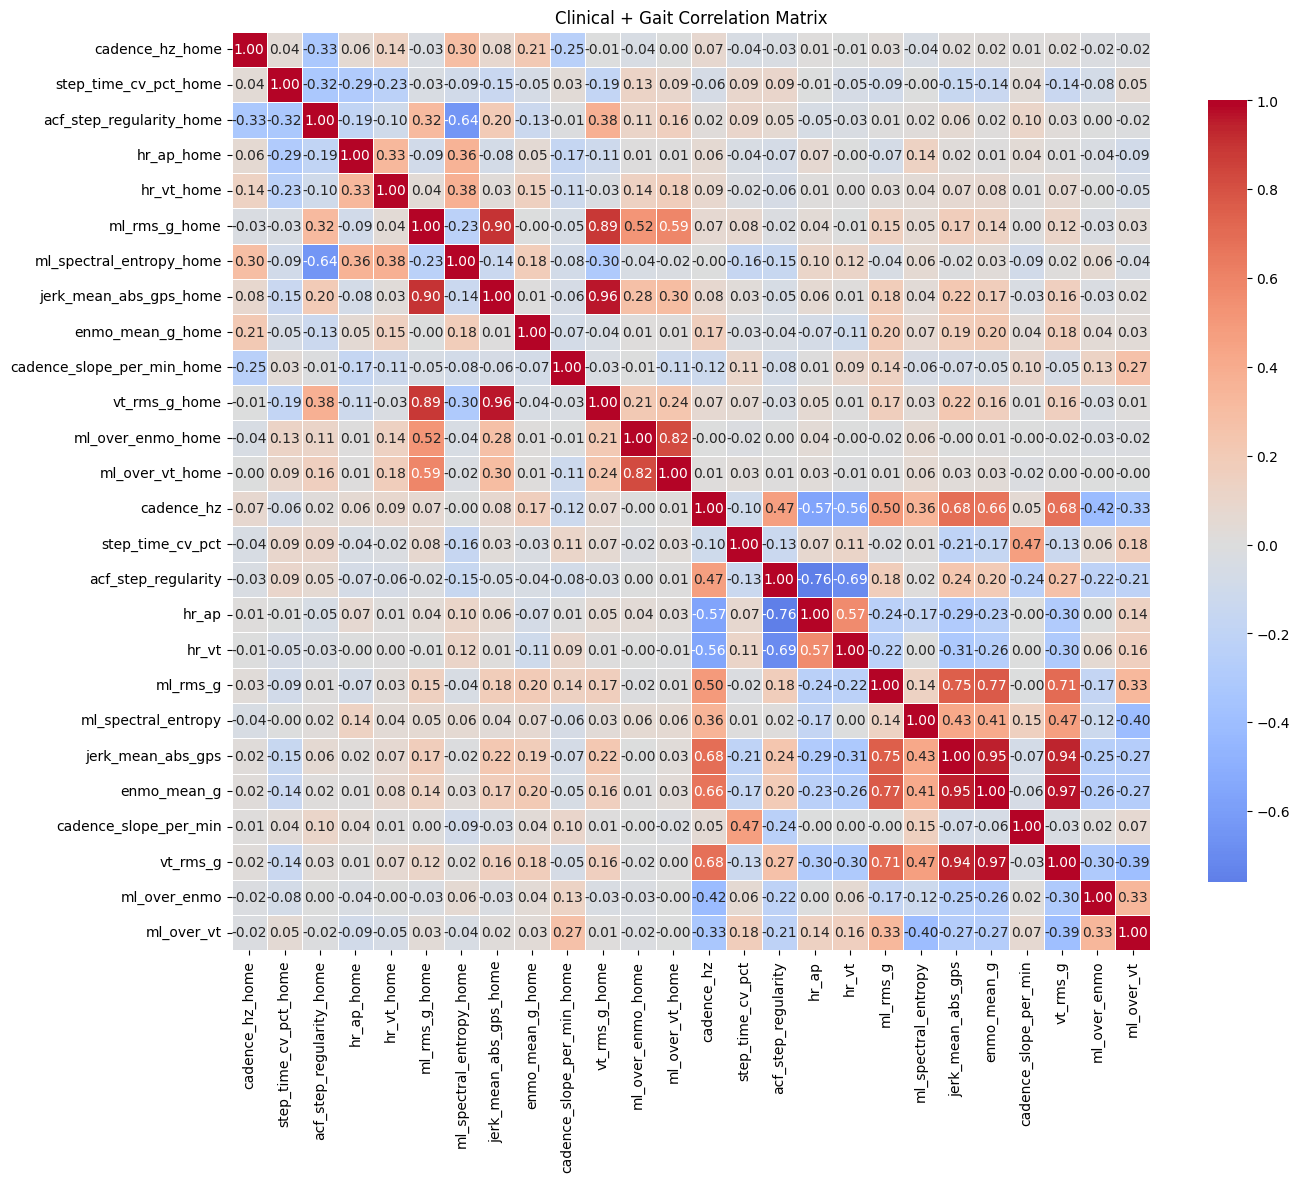

In [62]:
corr = merged.corr()

plt.figure(figsize=(14,12))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink":0.8}
)
plt.title("Clinical + Gait Correlation Matrix")
plt.tight_layout()
plt.show()